Day 1

In [40]:
!pip install streamlit -q
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer(as_frame = True)
df = data.frame


Day 2

(569, 31)


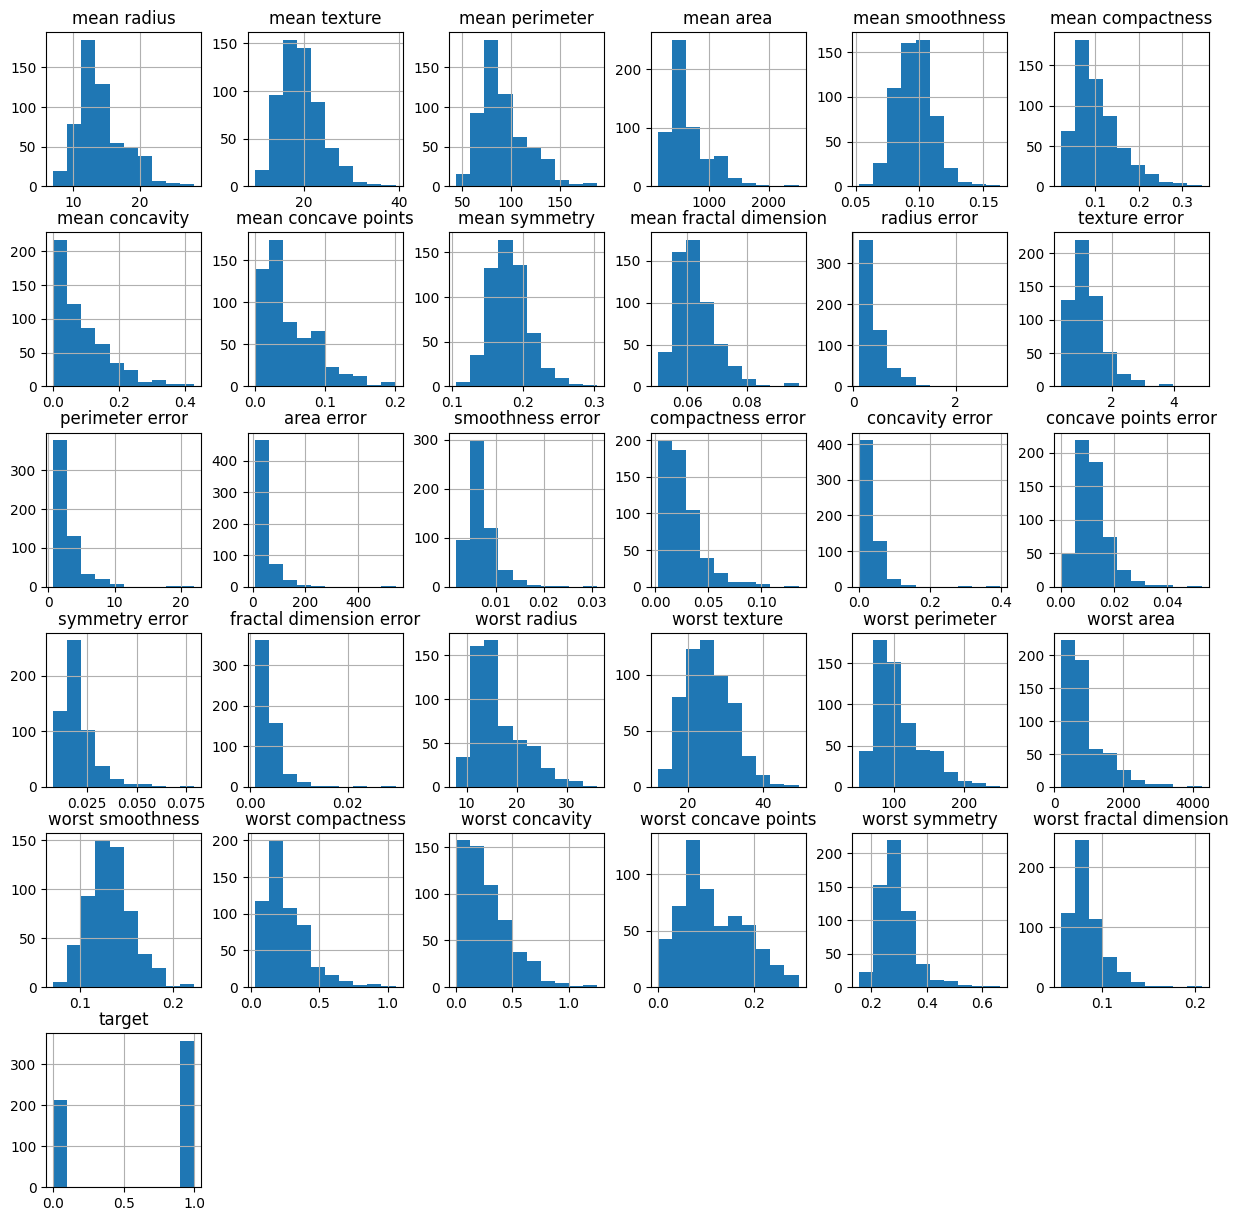

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [41]:
print(df.shape)
df.describe()
df['target'].value_counts()
import matplotlib.pyplot as plt
df.hist(figsize= (15,15))
plt.show()
df.head()

The data comes from digital images of a tumor sample (a needle biopsy).Each image contains many cell nuclei, so the measurements are make like this:
1. For each nucleus in the image, 10 properties are measured: radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry, fractal dimension.
2. Because one patient has many nuclei, those numbers are summarized into 3 values per property:


*  mean: the average across all nuclei in the image.
*   error: how much the values vary.(standard error)   
*   worst: the average the three largest values among the nuclei.





Day 3

In [42]:
print(df.isnull().sum())
#df.isnull() asks of every cell, "Is this empty?" and answers True or False
#Then .sum() counts the Trues in each column (Python treats True as 1 and False as 0)
#Every zero means "nothing is missing in this column."
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(df.drop(columns=['target']))
#Scaling puts all features on a fair, comparable footing.
#fit = the scaler calculates the average and spread of each column
#transform = it applies the formula using those numbers
#formula :new value = (value − column average) / column standard deviation

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64


Day 4

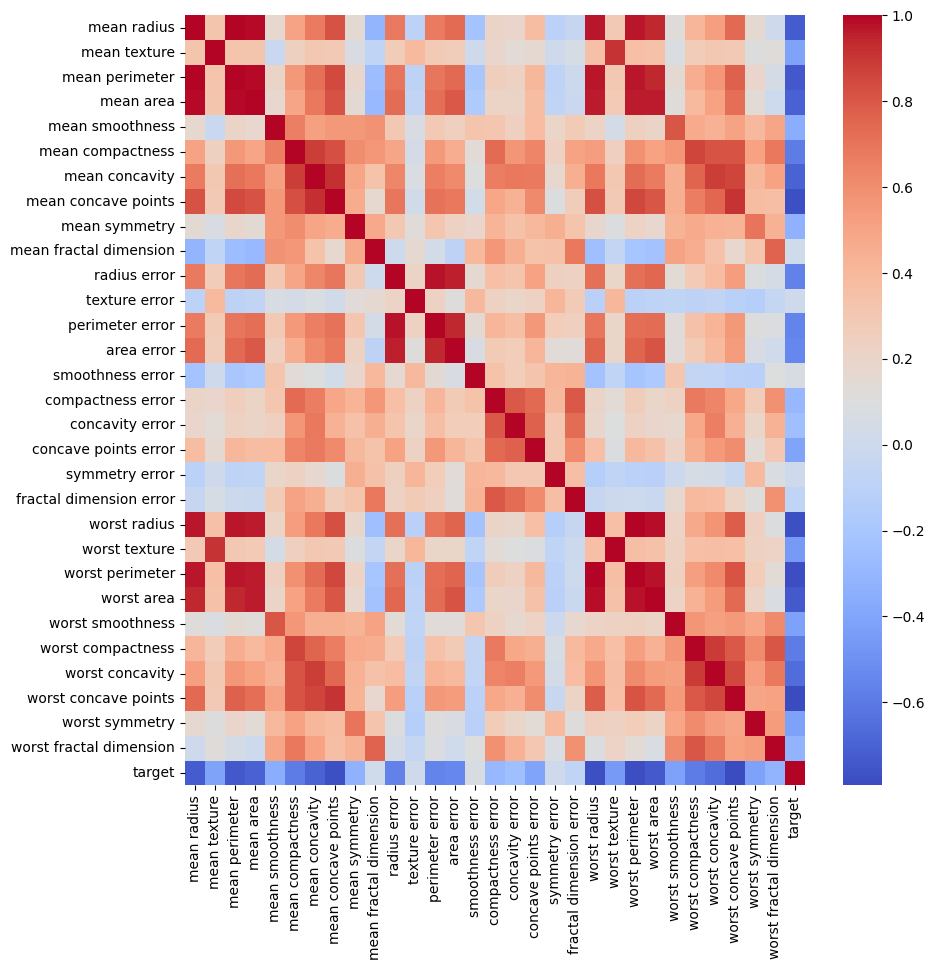

In [43]:
import seaborn as sns
plt.figure(figsize = (10,10))
sns.heatmap(df.corr(), annot=False, cmap= 'coolwarm')
plt.show()


worst concave points      -0.793566
worst perimeter           -0.782914
mean concave points       -0.776614
worst radius              -0.776454
mean perimeter            -0.742636
worst area                -0.733825
mean radius               -0.730029
mean area                 -0.708984
mean concavity            -0.696360
worst concavity           -0.659610
mean compactness          -0.596534
worst compactness         -0.590998
radius error              -0.567134
perimeter error           -0.556141
area error                -0.548236
worst texture             -0.456903
worst smoothness          -0.421465
worst symmetry            -0.416294
mean texture              -0.415185
concave points error      -0.408042
mean smoothness           -0.358560
mean symmetry             -0.330499
worst fractal dimension   -0.323872
compactness error         -0.292999
concavity error           -0.253730
fractal dimension error   -0.077972
symmetry error             0.006522
texture error              0

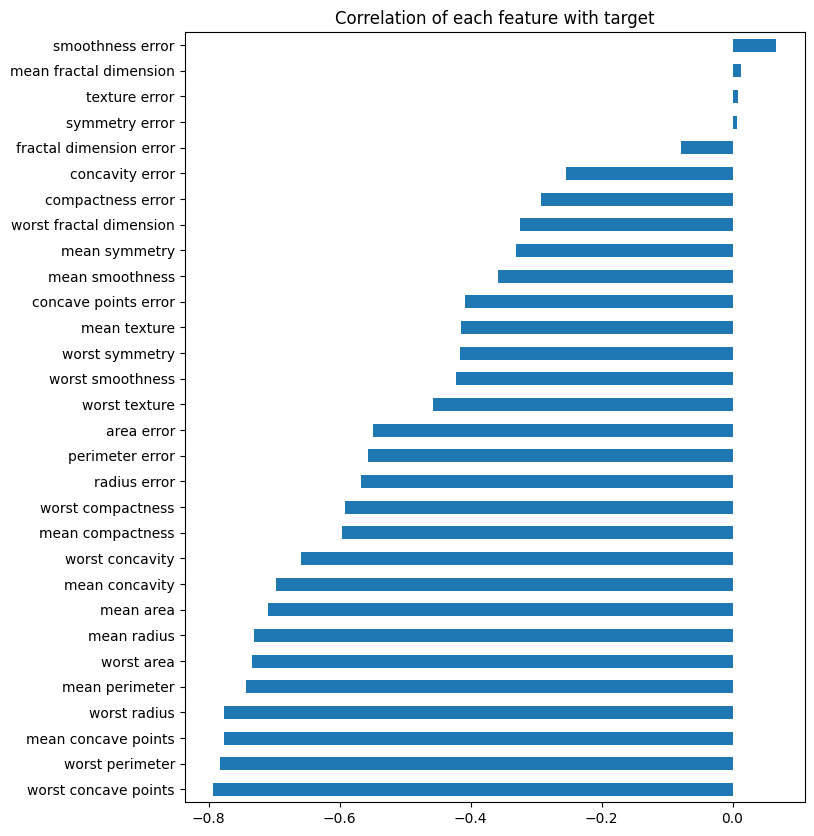

In [44]:
#which features correlate most with the target?
corr_with_target = df.corr()['target'].drop('target').sort_values()
print(corr_with_target)
corr_with_target.plot(kind='barh', figsize = (8,10))
plt.title('Correlation of each feature with target')
plt.show()

**Random Forest** (Day 5)

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, df['target'], test_size=0.2, random_state=42)
model= RandomForestClassifier(random_state=42)
model.fit(x_train, y_train)


RandomForestClassifier(random_state=42)

In [46]:
print("Training patients:", x_train.shape[0])
print("Testing patients:", x_test.shape[0])

Training patients: 455
Testing patients: 114


In [47]:
from sklearn.metrics import accuracy_score, classification_report

preds = model.predict(x_test)
print(accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

0.9649122807017544
              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



**Logistic Regression** (Day 6)

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
#Model 1: Random Forest
rf_preds = model.predict(x_test)
print("Random Forest accuracy:", accuracy_score(y_test, rf_preds))

#Model 2: Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state = 42)
lr_model.fit(x_train, y_train)
lr_preds = lr_model.predict(x_test)
print("Logistic Regression accuracy:", accuracy_score(y_test, lr_preds))
print(classification_report(y_test, lr_preds))
print(confusion_matrix(y_test, lr_preds))

Random Forest accuracy: 0.9649122807017544
Logistic Regression accuracy: 0.9736842105263158
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

[[41  2]
 [ 1 70]]


In [49]:
import pandas as pd
importances = pd.Series(model.feature_importances_,
                        index=df.drop(columns=['target']).columns)
print(importances.sort_values(ascending=False).head(10))
#This is the Random Forest's own ranking of how useful each feature was for making its decisions.
#Each number is a share of the total, and across all 30 features they add up to 1.0 (100%).

worst area              0.153892
worst concave points    0.144663
mean concave points     0.106210
worst radius            0.077987
mean concavity          0.068001
worst perimeter         0.067115
mean perimeter          0.053270
mean radius             0.048703
mean area               0.047555
worst concavity         0.031802
dtype: float64


Cancer cells are often large and irregular, and a sample can contain mostly normal cells plus a few abnormal ones. The mean can hide those few cells, but the worst value picks them up. That's why worst features rank higher than their mean versions.

In [50]:
from sklearn.preprocessing import StandardScaler
selected_features = ['worst area', 'worst concave points', 'mean concave points', 'worst radius', 'mean concavity']
x5 = df[selected_features]
x5_train, x5_test, y_train, y_test = train_test_split(
    x5, df['target'], test_size=0.2, random_state=42
)

scaler_5 = StandardScaler()
x5_train_scaled = scaler_5.fit_transform(x5_train)
x5_test_scaled = scaler_5.transform(x5_test)

#Random Forest on 5 features
rf_model_5 = RandomForestClassifier(random_state=42)
rf_model_5.fit(x5_train_scaled, y_train)
rf_preds_5 = rf_model_5.predict(x5_test_scaled)
print("Random Forest (5 features) accuracy:", accuracy_score(y_test, rf_preds_5))
print(classification_report(y_test, rf_preds_5))

#Logistic Regression on 5 features
lr_model_5 = LogisticRegression(max_iter=1000, random_state=42)
lr_model_5.fit(x5_train_scaled, y_train)
lr_preds_5 = lr_model_5.predict(x5_test_scaled)
print("Logistic Regression (5 features) accuracy:", accuracy_score(y_test, lr_preds_5))
print(classification_report(y_test, lr_preds_5))
print(confusion_matrix(y_test, lr_preds_5))

Random Forest (5 features) accuracy: 0.9473684210526315
              precision    recall  f1-score   support

           0       0.95      0.91      0.93        43
           1       0.95      0.97      0.96        71

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114

Logistic Regression (5 features) accuracy: 0.9736842105263158
              precision    recall  f1-score   support

           0       0.95      0.98      0.97        43
           1       0.99      0.97      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

[[42  1]
 [ 2 69]]


Day 7

In [51]:
import joblib
best_model= lr_model_5
joblib.dump(best_model, 'breast_cancer_model.joblib')
joblib.dump(scaler_5, 'scaler.joblib')
print("Model saved as 'breast_cancer_model.joblib'")

Model saved as 'breast_cancer_model.joblib'


In [52]:
loaded_model = joblib.load('breast_cancer_model.joblib')
loaded_scaler = joblib.load('scaler.joblib')
print("Model loaded back successfully! Ready to make predictions.")

Model loaded back successfully! Ready to make predictions.


In [53]:
def predict_tumor(worst_area, worst_concave_points, mean_concave_points, worst_radius, mean_concavity):
    input_data = pd.DataFrame(
        [[worst_area, worst_concave_points, mean_concave_points, worst_radius, mean_concavity]],
        columns = selected_features
    )
    scaled_input = loaded_scaler.transform(input_data)
    result = loaded_model.predict(scaled_input)[0]
    probability = loaded_model.predict_proba(scaled_input)[0]

    label = "Benign (Non cancerous)" if result== 1 else "Malignant (cancerous)"
    confidence = max(probability)*100
    return f"Prediction: {label}\nConfidence: {confidence: .2f}%"
print("Prediction function created!")

Prediction function created!


In [54]:
#First patient in the dataset
print(predict_tumor(2019.0, 0.2654, 0.1471, 25.38, 0.3001))

Prediction: Malignant (cancerous)
Confidence:  100.00%


Day 8

In [55]:
%%writefile app.py
import streamlit as st
import joblib
import pandas as pd
import numpy as np

model = joblib.load('breast_cancer_model.joblib')
scaler = joblib.load('scaler.joblib')

selected_features = ['worst area', 'worst concave points', 'mean concave points', 'worst radius', 'mean concavity']
st.title("AI Healthcare Predictor")
st.write('Enter the values below to get a prediction.')
st.markdown(
    """
    @import url('https://fonts.googleleapis.com/css2?family=Nunito:wght@600;700&display=swap');
    <style>
        .health-title{
            font-family:'Nunito', sans-serif;
            font-weight: 700;
            font-size: 42px;
            color: #0F6E8C; /*calm medical teal-blue*/
            margin-bottom: 0;
            }
        .health-subtitle {
            font-family: 'Nunito', sans-serif;
            font-weight: 600;
            font-size: 18px;
            color: #5F7A86;
            }
    </style>
    <h1 class="health-title".Patient Care Dashboard</h1>
    <p class="health-subtitle">Monitoring and insights for better health outcomes</p>
    """,
    unsafe_allow_html=True,
    )

worst_area = st.number_input('Worst Area', min_value=0.0, value=880.0, format="%.4f")
worst_cp = st.number_input('Worst Concave Points',min_value=0.0, value=0.11, format="%.4f")
mean_cp = st.number_input('Mean Concave Points', min_value=0.0, value=0.05, format="%.4f")
worst_radius = st.number_input('Worst Radius', min_value=0.0, value=16.3, format="%.4f")
mean_concavity = st.number_input('Mean Concavity', min_value=0.0, value=0.09, format="%.4f")

if st.button('Predict'):
    input_data = pd.DataFrame([[worst_area, worst_cp, mean_cp, worst_radius, mean_concavity]],
                            columns= selected_features)
    scaled_input = scaler.transform(input_data)
    result = model.predict(scaled_input)
    probability = model.predict_proba(scaled_input)[0]

    if result == 0:
        st.error(f'Prediction: Malignant (confidence {probability[0]:.1%})')
    else:
        st.success(f'Prediction:Benign (confidence {probability[0]:.1%})')


Overwriting app.py


In [60]:
%%writefile requirements.txt
streamlit
scikit-learn
pandas
joblib
numpy


Writing requirements.txt


In [61]:
from google.colab import files
files.download('app.py')
files.download('breast_cancer_model.joblib')
files.download('scaler.joblib')
files.download('requirements.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>